In [ ]:
"10 is greater" if 10>2 else "10 is smaller"

'10 is greater'

In [ ]:
!pip install numpy
!pip install pandas
!pip install scipy
!pip install scikit-learn
!pip install matplotlib
!pip install statsmodels
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

In [3]:
import pandas as pd

data = {
"Student_ID":[1,2,3,4,5,6,7,8,9,10],
"Name":["Ayaan","Sara","Ali","Zoya","Omar","Fatima","Imran","Aisha","Usman","Noor"],
"Age":[20,21,19,22,20,21,23,20,22,21],
"Hours_Studied":[2,4,1,5,3,6,2,4,3,5],
"Attendance_Percent":[75,82,60,90,70,95,65,85,80,92],
"Assignments_Submitted":[5,6,4,8,6,9,5,7,6,8],
"Final_Score":[55,65,45,78,60,88,50,72,66,84]
}

df = pd.DataFrame(data)
df.to_csv("student_data.csv", index=False)

print("CSV file created")

CSV file created


In [4]:


# Load the CSV file
df = pd.read_csv("student_data.csv")




In [6]:

# Show first few rows

df.head()

,Student_ID,Name,Age,Hours_Studied,Attendance_Percent,Assignments_Submitted,Final_Score
0,1,Ayaan,20,2,75,5,55
1,2,Sara,21,4,82,6,65
2,3,Ali,19,1,60,4,45
3,4,Zoya,22,5,90,8,78
4,5,Omar,20,3,70,6,60


In [5]:
# Describe the dataset
df.describe()

,Student_ID,Age,Hours_Studied,Attendance_Percent,Assignments_Submitted,Final_Score
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,20.900000,3.500000,79.400000,6.400000,66.300000
std,3.02765,1.197219,1.581139,11.758685,1.577621,14.306564
min,1.00000,19.000000,1.000000,60.000000,4.000000,45.000000
25%,3.25000,20.000000,2.250000,71.250000,5.250000,56.250000
50%,5.50000,21.000000,3.500000,81.000000,6.000000,65.500000
75%,7.75000,21.750000,4.750000,88.750000,7.750000,76.500000
max,10.00000,23.000000,6.000000,95.000000,9.000000,88.000000


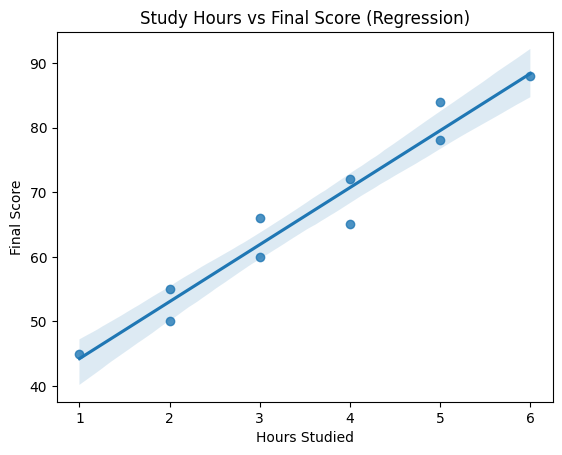

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_data.csv")

# X and Y variables
x = df["Hours_Studied"]
y = df["Final_Score"]

# Seaborn regression plot
sns.regplot(x=x, y=y)

# Labels
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score (Regression)")

plt.show()

In [8]:
# import pandas as pd
# import statsmodels.api as sm

# Load dataset
# df = pd.read_csv("student_data.csv")

# # Independent variable (X)
# X = df["Hours_Studied"]

# # Dependent variable (Y)
# Y = df["Final_Score"]

# Add constant (intercept)
X = sm.add_constant(X)

# Build OLS model
model = sm.OLS(Y, X)

# Fit model
results = model.fit()

# Show summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            Final_Score   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     154.1
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.65e-06
Time:                        09:38:50   Log-Likelihood:                -25.225
No. Observations:                  10   AIC:                             54.45
Df Residuals:                       8   BIC:                             55.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            35.4222      2.706     13.091

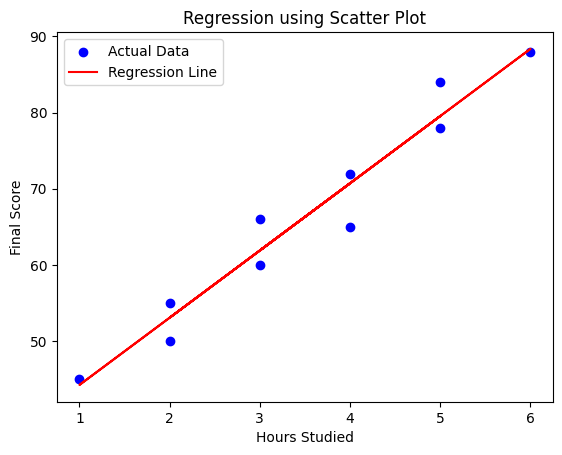

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_data.csv")

# X variable
x1 = df["Hours_Studied"]

# Y variable
y = df["Final_Score"]
# Regression coefficients
b1, b0 = np.polyfit(x1, y, 1)

# Predicted values (yhat)
yhat = b1*x1 + b0

# Scatter plot
plt.scatter(x1, y, color="blue", label="Actual Data")

# Regression line
plt.plot(x1, yhat, color="red", label="Regression Line")

# Labels
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.title("Regression using Scatter Plot")

plt.legend()
plt.show()

In [11]:
# Find regression coefficients
m, b = np.polyfit(x, y, 1)

# New data with same structure
new_data = {
    "Student_ID":[11,12,13],
    "Name":["Rahul","Aman","Sana"],
    "Age":[21,22,20],
    "Hours_Studied":[3,5,4],
    "Attendance_Percent":[80,90,85],
    "Assignments_Submitted":[6,8,7]
}

# Create dataframe
new_df = pd.DataFrame(new_data)

# Prediction using regression equation
new_df["Predicted_Score"] = m * new_df["Hours_Studied"] + b

print(new_df)

   Student_ID   Name  Age  Hours_Studied  Attendance_Percent  \
0          11  Rahul   21              3                  80   
1          12   Aman   22              5                  90   
2          13   Sana   20              4                  85   

   Assignments_Submitted  Predicted_Score  
0                      6        61.888889  
1                      8        79.533333  
2                      7        70.711111  


Example of dummy variable

In [12]:
import pandas as pd
import statsmodels.api as sm

# Load dataset
df = pd.read_csv("student_data.csv")

# Copy raw data into new variable
new_data = df.copy()

# Create dummy variable
# Example: Attendance >= 80 -> 1 else 0
new_data["High_Attendance"] = (new_data["Attendance_Percent"] >= 80).astype(int)

# Independent variables
X = new_data[["Hours_Studied", "High_Attendance"]]

# Dependent variable
Y = new_data["Final_Score"]

# Add constant
X = sm.add_constant(X)

# Linear Regression Model
model = sm.OLS(Y, X).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Final_Score   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     72.83
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.06e-05
Time:                        09:53:09   Log-Likelihood:                -24.858
No. Observations:                  10   AIC:                             55.72
Df Residuals:                       7   BIC:                             56.62
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              36.3667      3.074     

scattering with yhat yes & no

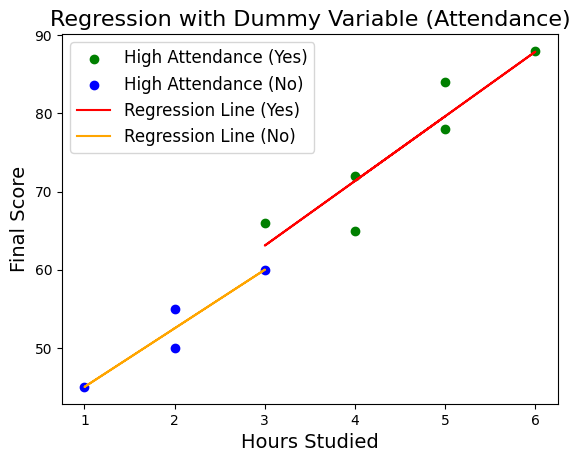

In [13]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("student_data.csv")

# Create dummy variable
df["High_Attendance"] = (df["Attendance_Percent"] >= 80).astype(int)

# Split data
yes = df[df["High_Attendance"] == 1]
no = df[df["High_Attendance"] == 0]

# Regression for YES
X_yes = sm.add_constant(yes["Hours_Studied"])
model_yes = sm.OLS(yes["Final_Score"], X_yes).fit()
yhat_yes = model_yes.predict(X_yes)

# Regression for NO
X_no = sm.add_constant(no["Hours_Studied"])
model_no = sm.OLS(no["Final_Score"], X_no).fit()
yhat_no = model_no.predict(X_no)

# Scatter plot
plt.scatter(yes["Hours_Studied"], yes["Final_Score"], color="green", label="High Attendance (Yes)")
plt.scatter(no["Hours_Studied"], no["Final_Score"], color="blue", label="High Attendance (No)")

# Regression lines
plt.plot(yes["Hours_Studied"], yhat_yes, color="red", label="Regression Line (Yes)")
plt.plot(no["Hours_Studied"], yhat_no, color="orange", label="Regression Line (No)")

# Labels with font size
plt.xlabel("Hours Studied", fontsize=14)
plt.ylabel("Final Score", fontsize=14)
plt.title("Regression with Dummy Variable (Attendance)", fontsize=16)

plt.legend(fontsize=12)
plt.show()